Setup:

In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.seqlen = model.config.max_position_embeddings

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# from llm import find_layers

# find_layers(model)

# length = 0
# for name, param in model.named_parameters():
#     if 'proj' in name:
#         print(name, param.shape)
#         length += 1
# print(f'Matrix count: {length}')

In [4]:
model.hf_device_map

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [5]:
o_proj_weight = model.model.layers[21].mlp.gate_proj.weight
print(o_proj_weight.shape)   # torch.Size([1024, 4096])
print(o_proj_weight.device)
print(o_proj_weight.dtype)
print(o_proj_weight)

k_proj_weight = model.model.layers[5].self_attn.k_proj.weight
print(k_proj_weight.shape)   # torch.Size([1024, 4096])
print(k_proj_weight.device)
print(k_proj_weight.dtype)
print(k_proj_weight)

mlp_down_weight = model.model.layers[8].mlp.down_proj.weight
# print(mlp_up_weight.shape)   # torch.Size([14336, 4096])
# print(mlp_up_weight.device)
# print(mlp_up_weight.dtype)
# print(mlp_up_weight)


torch.Size([11008, 4096])
cuda:1
torch.float16
Parameter containing:
tensor([[-0.0027, -0.0205,  0.0111,  ..., -0.0300,  0.0410,  0.0151],
        [ 0.0141,  0.0108,  0.0090,  ..., -0.0359,  0.0496,  0.0058],
        [ 0.0145,  0.0069,  0.0024,  ..., -0.0425, -0.0048, -0.0198],
        ...,
        [ 0.0122, -0.0266, -0.0291,  ...,  0.0344, -0.0254,  0.0005],
        [-0.0023,  0.0312,  0.0081,  ...,  0.0096, -0.0219,  0.0052],
        [ 0.0015, -0.0108, -0.0025,  ..., -0.0159,  0.0013,  0.0072]],
       device='cuda:1', dtype=torch.float16, requires_grad=True)
torch.Size([4096, 4096])
cuda:0
torch.float16
Parameter containing:
tensor([[-0.0145,  0.0295,  0.0062,  ...,  0.0155, -0.0024, -0.0049],
        [ 0.0015, -0.0009, -0.0298,  ...,  0.0187, -0.0081,  0.0344],
        [-0.0082, -0.0168,  0.0007,  ...,  0.0046, -0.0104,  0.0037],
        ...,
        [ 0.0073, -0.0007, -0.0234,  ...,  0.0371,  0.0079, -0.0299],
        [ 0.0542,  0.0209, -0.0181,  ..., -0.0014, -0.0156, -0.0361],
 

Tests:

In [6]:
from test_dbsf import *

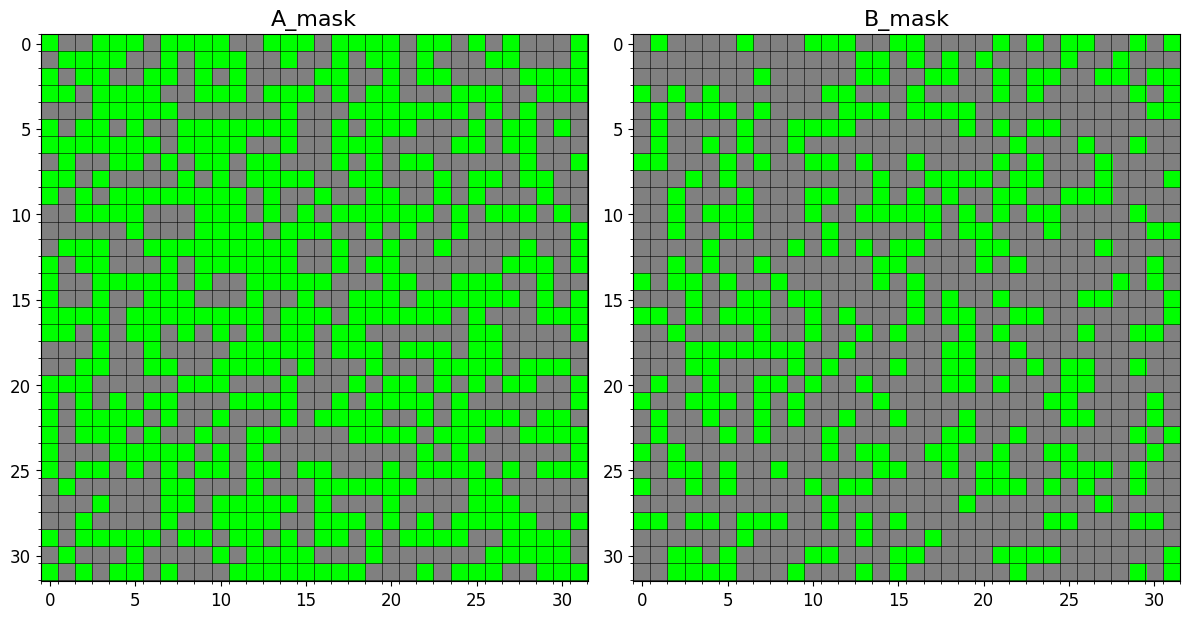

Frobenius norm: 21.61227035522461
A: tensor([[-0.0000, -0.0000,  0.0000, -0.0244],
        [ 0.0257,  0.0000,  0.0000, -0.0000],
        [-0.0000, -0.0000,  0.0000, -0.0671],
        [-0.0000,  0.0000,  0.0000, -0.0000]])
B: tensor([[ 0.8494,  0.0000,  0.0122,  0.0049],
        [ 0.0000,  0.8514,  0.0000, -0.0187],
        [ 0.0000,  0.0040,  0.8250, -0.0000],
        [-0.0239,  0.0302,  0.0147,  0.8456]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-3.3427e-03, -1.9523e-02,  1.8766e-02,  ..., -2.8676e-02,
          3.1393e-02,  1.5204e-02],
        [ 1.2302e-02,  1.1347e-02,  4.3286e-03,  ..., -3.7023e-02,
          5.0168e-02,  2.6128e-03],
        [ 1.7495e-02,  9.7316e-03,  2.7918e-03,  ..., -4.1102e-02,
         -8.5879e-03, -2.1217e-02],
        ...,
        [ 7.3254e-03, -3.0564e-02, -2.2696e-02,  ...,  3.5878e-02,
         -2.9345e-02,  2.5381e-03],
        [ 7.2075e-04,  3.0404e-02,  2.9697e-03,  ...,  8.7996e-03,
         -2.1782e-02,

In [7]:
a = test_double_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

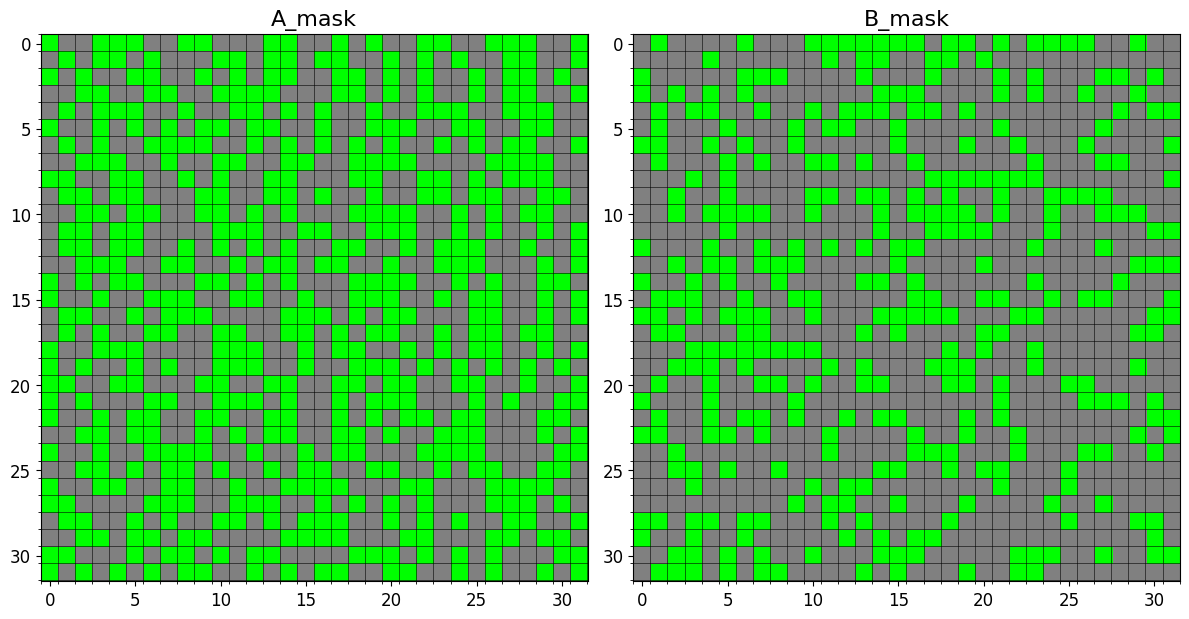

Frobenius norm: 23.525968551635742
A: tensor([[ 0.0000,  0.0000,  0.0338, -0.0285],
        [ 0.0288,  0.0000,  0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0500],
        [-0.0000, -0.0000, -0.0000, -0.0000]])
B: tensor([[ 0.8606,  0.0000,  0.0180,  0.0000],
        [ 0.0000,  0.8618,  0.0000, -0.0000],
        [ 0.0000, -0.0000,  0.8521,  0.0202],
        [-0.0175,  0.0134,  0.0000,  0.8361]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0025, -0.0210,  0.0143,  ..., -0.0234,  0.0393,  0.0071],
        [ 0.0127,  0.0072,  0.0052,  ..., -0.0364,  0.0508,  0.0027],
        [ 0.0098,  0.0040,  0.0054,  ..., -0.0391, -0.0099, -0.0186],
        ...,
        [ 0.0067, -0.0323, -0.0292,  ...,  0.0334, -0.0242,  0.0005],
        [-0.0043,  0.0272,  0.0076,  ...,  0.0100, -0.0191,  0.0051],
        [ 0.0005, -0.0087,  0.0051,  ..., -0.0124,  0.0106,  0.0073]])
Input matrix was: tensor([[-0.0027, -0.0205,  0.0111,  ..., -0.0300,  0.0410, 

In [8]:
b = test_hybrid(matrix=o_proj_weight, asp=0.25, bsp=0.25)

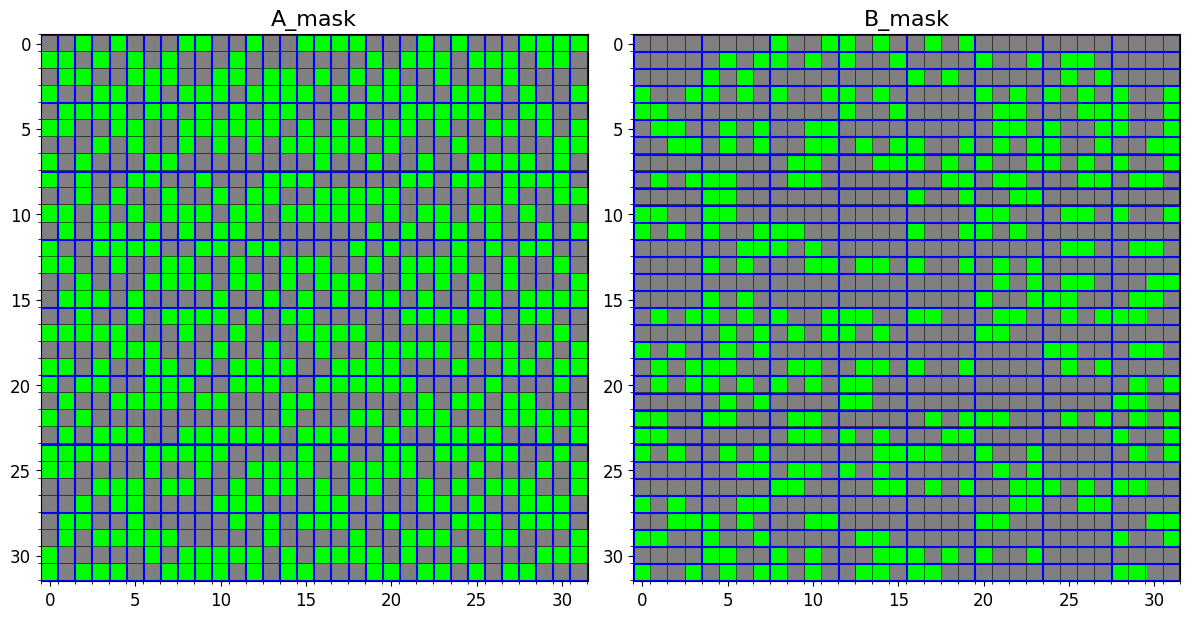

Frobenius norm: 28.209228515625
A: tensor([[0.0000, 0.0000, 0.0000, 0.0359],
        [0.0000, -0.0000, -0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0000, 0.0000],
        [0.0000, -0.0000, 0.0000, 0.0097]])
B: tensor([[ 0.0000, -0.0070,  0.0000,  0.0077],
        [-0.0000, -0.0547,  0.0439,  0.0000],
        [-0.0107, -0.0000, -0.0226,  0.0000],
        [ 0.0000, -0.0055,  0.0000, -0.0330]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 0.0019, -0.0156,  0.0109,  ..., -0.0295,  0.0347,  0.0131],
        [ 0.0047,  0.0098,  0.0056,  ..., -0.0357,  0.0491,  0.0003],
        [ 0.0195,  0.0078,  0.0068,  ..., -0.0435, -0.0073, -0.0158],
        ...,
        [ 0.0061, -0.0266, -0.0282,  ...,  0.0350, -0.0217,  0.0076],
        [ 0.0003,  0.0275,  0.0084,  ...,  0.0108, -0.0188,  0.0019],
        [ 0.0020, -0.0110, -0.0057,  ..., -0.0174, -0.0034,  0.0039]])
Input matrix was: tensor([[-0.0027, -0.0205,  0.0111,  ..., -0.0300,  0.0410,  0.0151],
  

In [9]:
c = test_2to4_A_B(matrix=o_proj_weight, sp=0.25, mid_dim_scale=1)

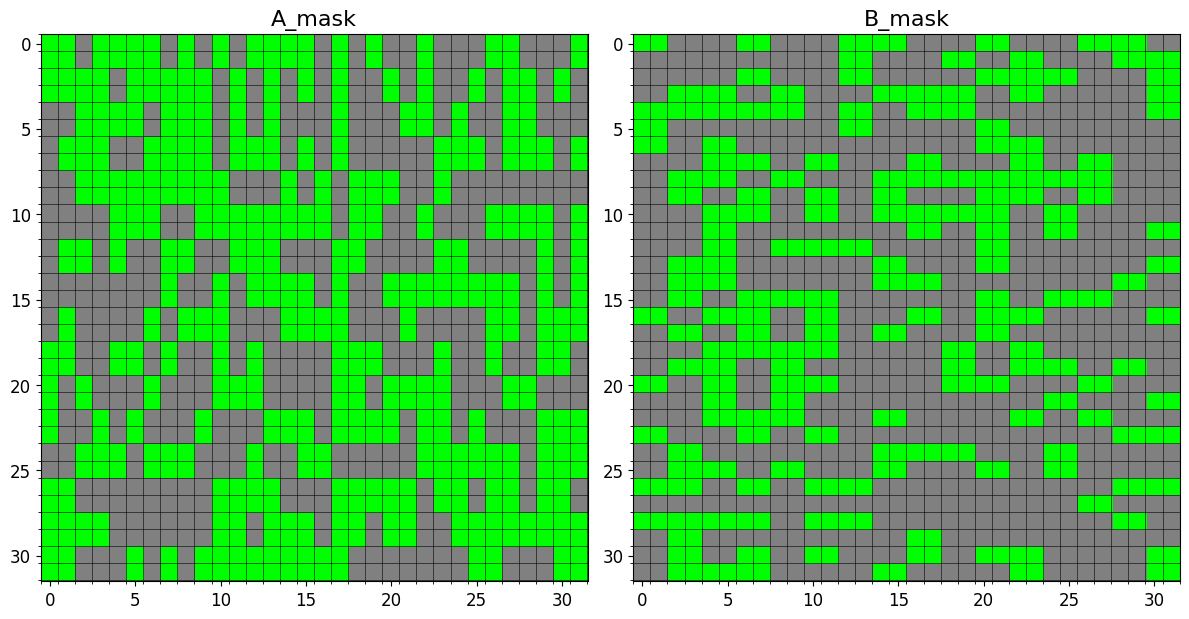

Frobenius norm: 33.86189651489258
A: tensor([[ 0.0094, -0.0000,  0.0000, -0.0000],
        [ 0.0280,  0.0000,  0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0641],
        [ 0.0000, -0.0000, -0.0000, -0.0053]])
B: tensor([[ 0.7946,  0.0172,  0.0487,  0.0138],
        [-0.0022,  0.8111,  0.0216,  0.0012],
        [-0.0000,  0.0000,  0.7870, -0.0137],
        [-0.0091,  0.0092,  0.0324,  0.7994]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0071, -0.0163,  0.0061,  ..., -0.0297,  0.0375,  0.0149],
        [ 0.0156,  0.0112,  0.0052,  ..., -0.0368,  0.0495,  0.0013],
        [ 0.0104,  0.0044,  0.0012,  ..., -0.0402, -0.0051, -0.0186],
        ...,
        [ 0.0062, -0.0244, -0.0323,  ...,  0.0285, -0.0165,  0.0018],
        [-0.0114,  0.0234,  0.0029,  ...,  0.0143, -0.0240, -0.0015],
        [ 0.0027, -0.0102, -0.0007,  ..., -0.0125,  0.0036,  0.0002]])
Input matrix was: tensor([[-0.0027, -0.0205,  0.0111,  ..., -0.0300,  0.0410,  

In [10]:
d = test_1x2_2x1(matrix=o_proj_weight, sp=0.25, mid_dim_scale=1)

In [11]:
e = test_mag_prune(matrix=o_proj_weight, sp=0.5)

Frobenius norm: 35.3125
AB: tensor([[-0.0000, -0.0205,  0.0000,  ..., -0.0300,  0.0410,  0.0151],
        [ 0.0141,  0.0000,  0.0000,  ..., -0.0359,  0.0496,  0.0000],
        [ 0.0145,  0.0000,  0.0000,  ..., -0.0425, -0.0000, -0.0198],
        ...,
        [ 0.0000, -0.0266, -0.0291,  ...,  0.0344, -0.0254,  0.0000],
        [-0.0000,  0.0312,  0.0000,  ...,  0.0000, -0.0219,  0.0000],
        [ 0.0000, -0.0000, -0.0000,  ..., -0.0159,  0.0000,  0.0000]],
       dtype=torch.float16)
Input matrix was: Parameter containing:
tensor([[-0.0027, -0.0205,  0.0111,  ..., -0.0300,  0.0410,  0.0151],
        [ 0.0141,  0.0108,  0.0090,  ..., -0.0359,  0.0496,  0.0058],
        [ 0.0145,  0.0069,  0.0024,  ..., -0.0425, -0.0048, -0.0198],
        ...,
        [ 0.0122, -0.0266, -0.0291,  ...,  0.0344, -0.0254,  0.0005],
        [-0.0023,  0.0312,  0.0081,  ...,  0.0096, -0.0219,  0.0052],
        [ 0.0015, -0.0108, -0.0025,  ..., -0.0159,  0.0013,  0.0072]],
       device='cuda:1', dtype=torch.

In [ ]:
f = test_double_block_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

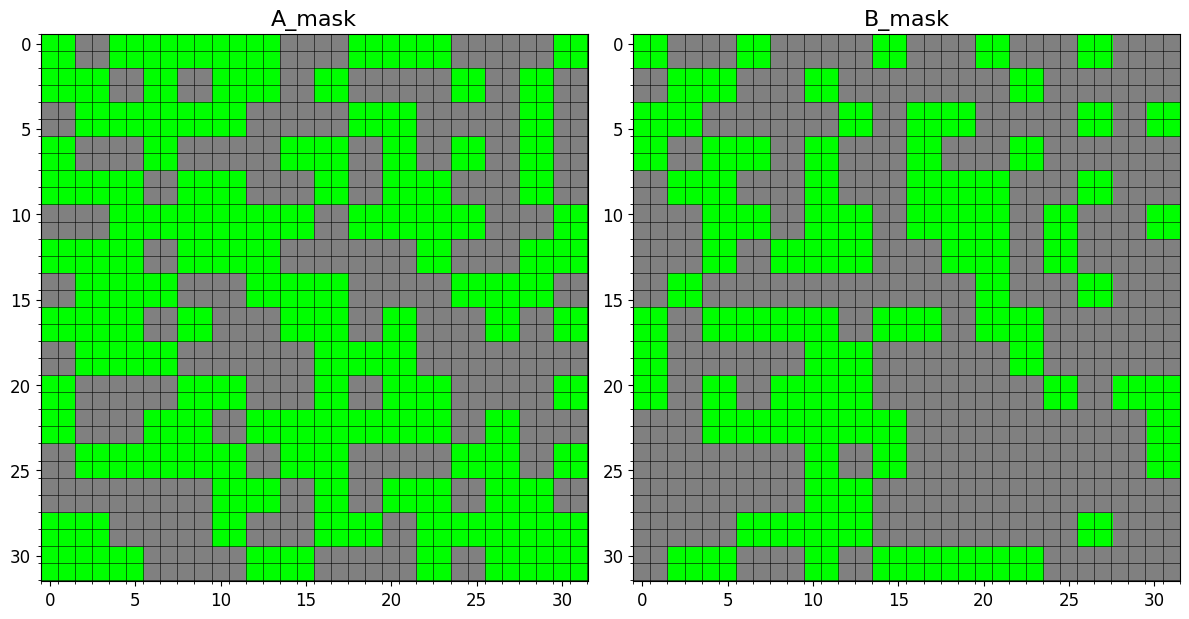

Frobenius norm: 44.18647766113281
A: tensor([[-0.0132,  0.0262, -0.0000, -0.0000],
        [ 0.0671, -0.0173,  0.0000,  0.0000],
        [ 0.0000, -0.0000, -0.0233, -0.0840],
        [ 0.0000, -0.0000,  0.0097, -0.0015]])
B: tensor([[ 7.4347e-01, -3.7916e-03,  4.9709e-02, -1.5946e-02],
        [ 7.7279e-03,  7.4171e-01,  2.9166e-03, -3.2486e-02],
        [-0.0000e+00,  0.0000e+00,  7.0739e-01,  1.6893e-02],
        [-0.0000e+00,  0.0000e+00, -3.9864e-04,  7.3548e-01]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0022, -0.0116,  0.0101,  ..., -0.0343,  0.0361,  0.0183],
        [ 0.0096,  0.0097,  0.0010,  ..., -0.0261,  0.0596,  0.0115],
        [ 0.0123,  0.0151,  0.0051,  ..., -0.0274, -0.0096, -0.0250],
        ...,
        [ 0.0071, -0.0157, -0.0252,  ...,  0.0334, -0.0198,  0.0026],
        [-0.0137,  0.0309,  0.0067,  ...,  0.0049, -0.0325, -0.0016],
        [ 0.0061, -0.0093, -0.0016,  ..., -0.0093, -0.0026,  0.0128]])
Input matrix wa

In [13]:
g = test_double_block_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [ ]:
h = test_2to4_A_B(matrix=o_proj_weight, sp=0.5, mid_dim_scale=0.5)

Output:

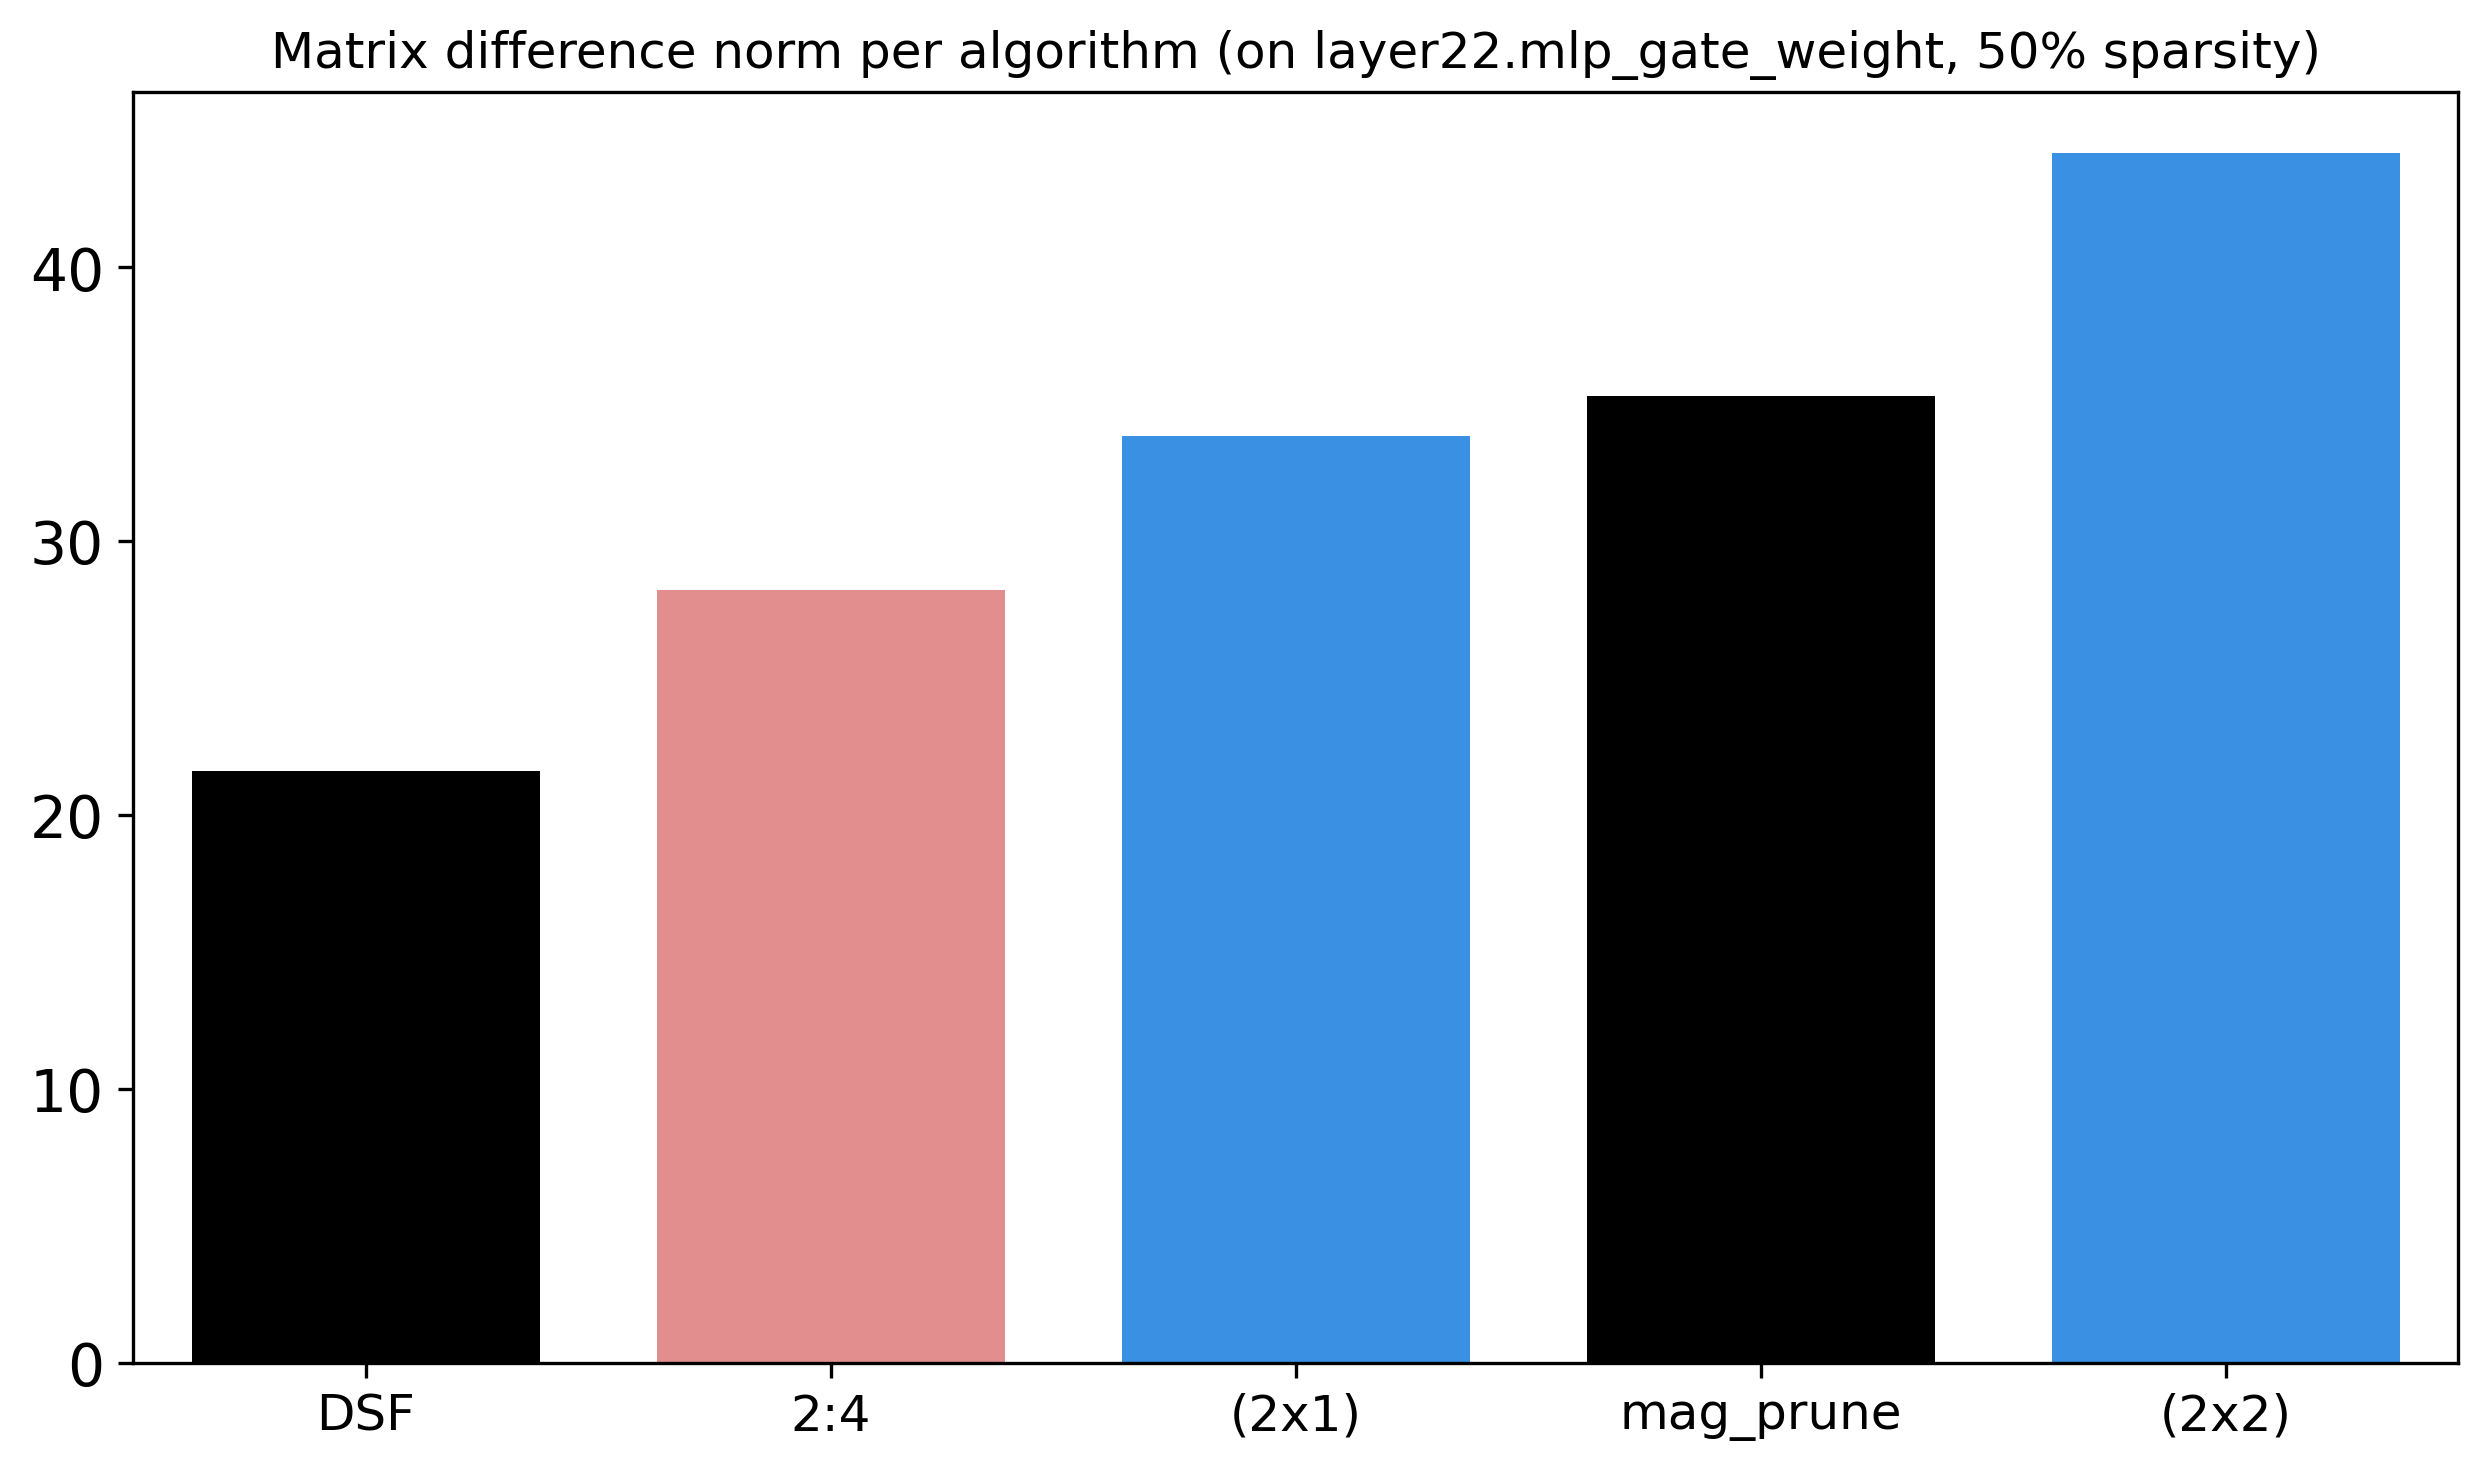

In [ ]:
import seaborn as sns
sns.reset_orig()

import textwrap

def wrap_labels(ax, width):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width))
    ax.set_xticklabels(labels)

from matplotlib import rcParams
rcParams['figure.figsize'] = 7, 4
rcParams['figure.dpi'] = 300

f_randn = 16.608356475830078
f_init = 17.882638931274414
outputs = {'DSF': 21.612, # 'DSF': 7.11,
        #    'hybrid': b, 
           '2:4': c,
           '(2x1)': d,
           'mag_prune': e,
        #    '(2x2)\n(2x middle\ndimension,\nrand init)': f,
        #    '(2x2)\n(2x middle\ndimension,\nrandn init)': f_randn,
           '(2x2)': g,
           '2:4\n(0.5x middle\ndimension)': h,
        #    '(2x2)\n(2x middle\ndimension,\nidentity init)': f_init,
           }
# alpha = [1, 1, 1, 1, 1, 1, 1, 1, 1]
alpha = [1, 1, 1, 1, 1,]
colors = [
    "black", 
    "lightcoral", 
    "dodgerblue", 
    "black", 
    # "dodgerblue", 
    # "dodgerblue", 
    "dodgerblue", 
    # "lightcoral", 
    # "dodgerblue"
]
bars = sns.barplot(x = outputs.keys(), y = outputs.values(), palette=colors, hue=outputs.keys(), legend=False, width=0.75)
bars.tick_params(axis='x', labelsize=12)
bars.tick_params(axis='y', labelsize=14)
bars.yticks(np.arange(0, 71, 10))

bars.set_title('Matrix difference norm per algorithm (on layer22.mlp_gate_weight, 50% sparsity)')
# wrap_labels(bars, 10)
for bar, a in zip(bars.patches, alpha):
    bar.set_alpha(a)

Cleanup:

In [16]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()